### <p style="text-align: center;"> **Name:** Shahzaib Khan &ensp;&ensp;&ensp;&ensp;&ensp;&ensp; **Roll No:** 19K-0273 &ensp;&ensp;&ensp;&ensp;&ensp;&ensp; **Section:** BCS-8B</p>

## K-Means Clustering
This notebook implements K-Means clustering on the Wholesale customers dataset using 4 features (Fresh, Milk, Grocery, Frozen). The steps include:
- Loading and exploring the data
- Standardizing the data
- Computing the elbow plot to determine the optimal number of clusters
- Applying K-Means clustering with k=5
- Performing silhouette analysis
- Analyzing the results and findings

In [121]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

%matplotlib inline
plt.style.use('fivethirtyeight')

In [122]:
# Reading the data
data = pd.read_csv('data/wholesale_customers_data.csv')
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [123]:
# Statistics of the data
data.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [124]:
# Verify no missing values (optional step)
assert data.isnull().sum().sum() == 0, 'Missing values detected'

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

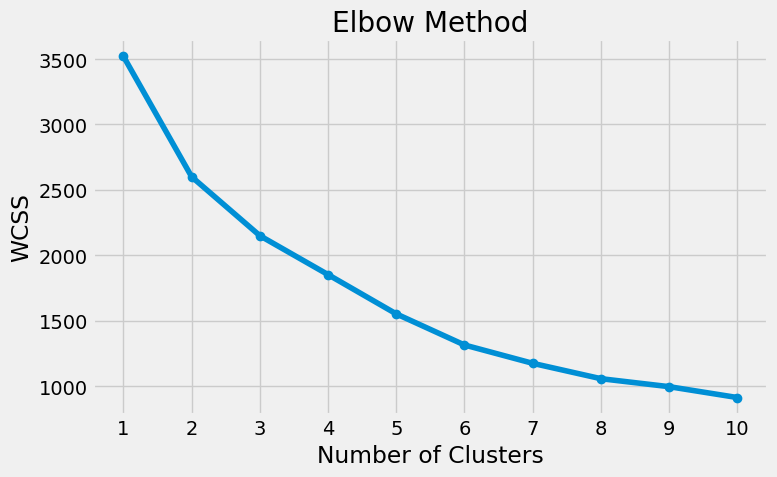

In [125]:
# Elbow method to find optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

In [126]:
# Apply K-Means with k=5
kmeans_kwargs = {'init': 'k-means++', 'n_init': 10, 'max_iter': 300, 'random_state': 42}
kmeans = KMeans(n_clusters=5, **kmeans_kwargs)
kmeans.fit(scaled_data)

# K-Means with random initialization
kmeans_random = KMeans(n_clusters=5, init='random', n_init=10, max_iter=300, random_state=42)
kmeans_random.fit(scaled_data)

KMeans(init='random', n_clusters=5, n_init=10, random_state=42)

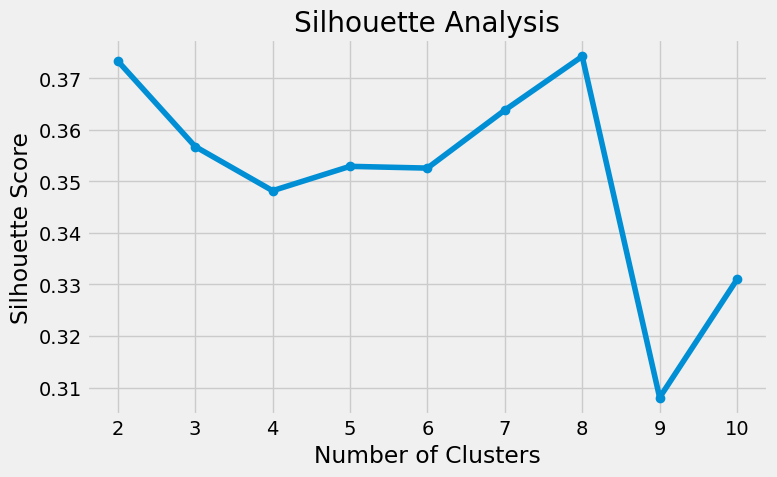

In [127]:
# Silhouette analysis
silhouette_scores = []
for k in range(2, 11): # start from 2 clusters to avoid trivial case
    kmeans_temp = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans_temp.fit(scaled_data)
    score = silhouette_score(scaled_data, kmeans_temp.labels_)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xticks(range(2, 11))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

In [128]:
print("Results:-")
print(f'Inertia (k=5, k-means++): {kmeans.inertia_:.3f}')
print(f'Inertia (k=5, random): {kmeans_random.inertia_:.3f}')
print(f'Cluster Sizes (k-means++): {np.bincount(kmeans.labels_)}') # extra step
print(f'Cluster Sizes (random): {np.bincount(kmeans_random.labels_)}') # extra step
print(f'Convergence (k-means++): {kmeans.n_iter_}')
print(f'Convergence (random): {kmeans_random.n_iter_}')
print(f'Silhouette Scores: {[float(round(s, 3)) for s in silhouette_scores]}')

Results:-
Inertia (k=5, k-means++): 1551.668
Inertia (k=5, random): 1559.512
Cluster Sizes (k-means++): [  6 126  91 207  10]
Cluster Sizes (random): [203  10  10  91 126]
Convergence (k-means++): 4
Convergence (random): 11
Silhouette Scores: [0.373, 0.357, 0.348, 0.353, 0.353, 0.364, 0.374, 0.308, 0.331]


## Analysis

### Effect of Centroid Initialization
- **k-means++**: This method selects initial centroids to maximize inter-centroid distance, leading to better convergence with lower inertia. It reduces the likelihood of poor clustering due to suboptimal initial placements.
- **Random Initialization**: Results in higher inertia, indicating less optimal clustering. Random centroids are more likely to start in less representative positions, potentially converging to local minima.

### Strategies for Better Initialization
1. **K-Means++**: Used here, it probabilistically selects centroids to spread them out, improving convergence.
2. **Multiple Random Runs**: Increasing `n_init` (set to 10 here) runs K-Means multiple times and selects the best result based on inertia.
3. **Hierarchical Clustering**: Can be used to initialize centroids by identifying cluster centers from a dendrogram.
4. **Farthest Point Clustering**: Sequentially selects centroids farthest from existing ones to ensure diversity.

### Silhouette Analysis
- The silhouette scores show the highest value at k=8 (~0.374), indicating good cluster separation. However, k=5 (~0.353) is chosen based on the elbow plot, which shows a bend around k=5, balancing cluster quality and simplicity. Scores decrease slightly for k>8, suggesting potential overfitting with too many clusters.

### Sides Notes

1. **Selection of k=5**:
- The elbow plot (WCSS vs. k) shows a bend around k=5, where the reduction in WCSS slows, indicating that additional clusters beyond k=5 yield diminishing improvements in cluster compactness. This suggests k=5 balances tightness (low inertia) and simplicity.
- The silhouette analysis supports k=5 with a score of ~0.353, close to the maximum at k=8 (~0.374). We chose k=5 over k=8 to avoid overfitting and maintain interpretable customer segments.

2. **Individual Cluster Visualization**: 
-  cluster visualization (e.g., scatter plots of clusters) was omitted to focus on the algorithm's performance metrics, such as inertia and silhouette scores. Visualizing clusters is unnecessary for this analysis, as the goal is to evaluate the clustering process and centroid initialization strategies rather than interpret feature-specific behaviors or extract new features. The elbow and silhouette plots provide sufficient insight into the algorithm's effectiveness.